In [4]:
import pandas as pd
print("Notebook setup successful")

Notebook setup successful


In [5]:
df=pd.read_csv("../data/raw/yield_df.csv")

In [6]:
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [7]:
df.shape

(28242, 8)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [9]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [10]:
df.describe()

,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [11]:
df = df.drop("Unnamed: 0", axis=1) #dropping the counter column
df.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [12]:
#creating a function to classify the yield into three different categories
def classify_risk(yield_value):
    if yield_value < df["hg/ha_yield"].quantile(0.33):
        return "High Risk"
    elif yield_value < df["hg/ha_yield"].quantile(0.66):
        return "Medium Risk"
    else :
        return "Low Risk"

In [13]:
df["risk_level"]=df["hg/ha_yield"].apply(classify_risk) #creating the target variable

In [14]:
df[["hg/ha_yield","risk_level"]].head()

,hg/ha_yield,risk_level
0,36613,Medium Risk
1,66667,Medium Risk
2,23333,High Risk
3,12500,High Risk
4,7000,High Risk


In [15]:
df[["risk_level"]].value_counts()

risk_level 
Low Risk       9602
Medium Risk    9320
High Risk      9320
Name: count, dtype: int64

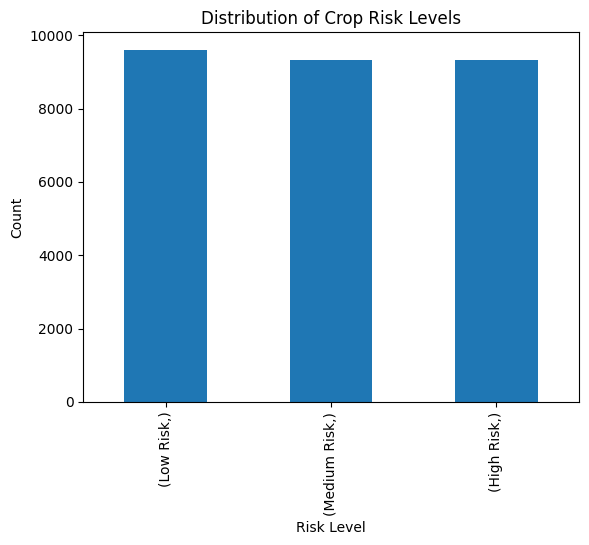

'The dataset shows a balanced distribution across all three risk levels, making it suitable for classification modeling without bias.'

In [16]:
import matplotlib.pyplot as plt
df[["risk_level"]].value_counts().plot(kind="bar")
plt.title("Distribution of Crop Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()
'''The dataset shows a balanced distribution across all three risk levels, making it suitable for classification modeling without bias.'''

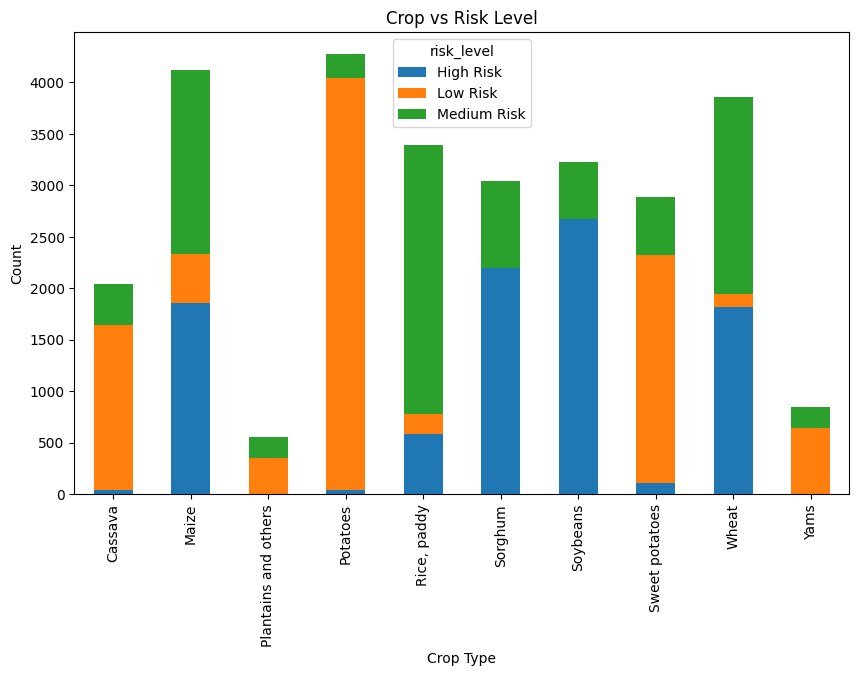

'Certain crops such as potatoes show a higher concentration in low-risk categories, whereas crops like soybeans exhibit relatively higher risk levels, indicating crop-specific sensitivity to environmental conditions'

In [17]:
# Crop vs Risk
crop_risk = df.groupby(["Item", "risk_level"]).size().unstack()

crop_risk.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Crop vs Risk Level")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()
'''Certain crops such as potatoes show a higher concentration in low-risk categories, whereas crops like soybeans exhibit relatively higher risk levels, indicating crop-specific sensitivity to environmental conditions'''

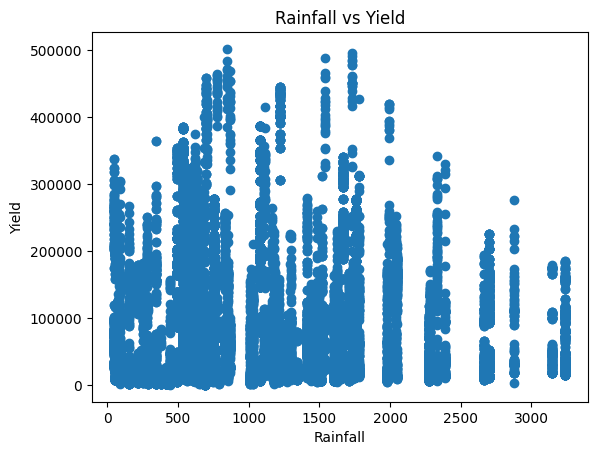

' Yield appears to be highest within a moderate rainfall range, while extreme rainfall levels are associated with reduced yields, suggesting an optimal rainfall threshold for crop productivity.'

In [18]:
plt.scatter(df["average_rain_fall_mm_per_year"], df["hg/ha_yield"])

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()
''' Yield appears to be highest within a moderate rainfall range, while extreme rainfall levels are associated with reduced yields, suggesting an optimal rainfall threshold for crop productivity.'''


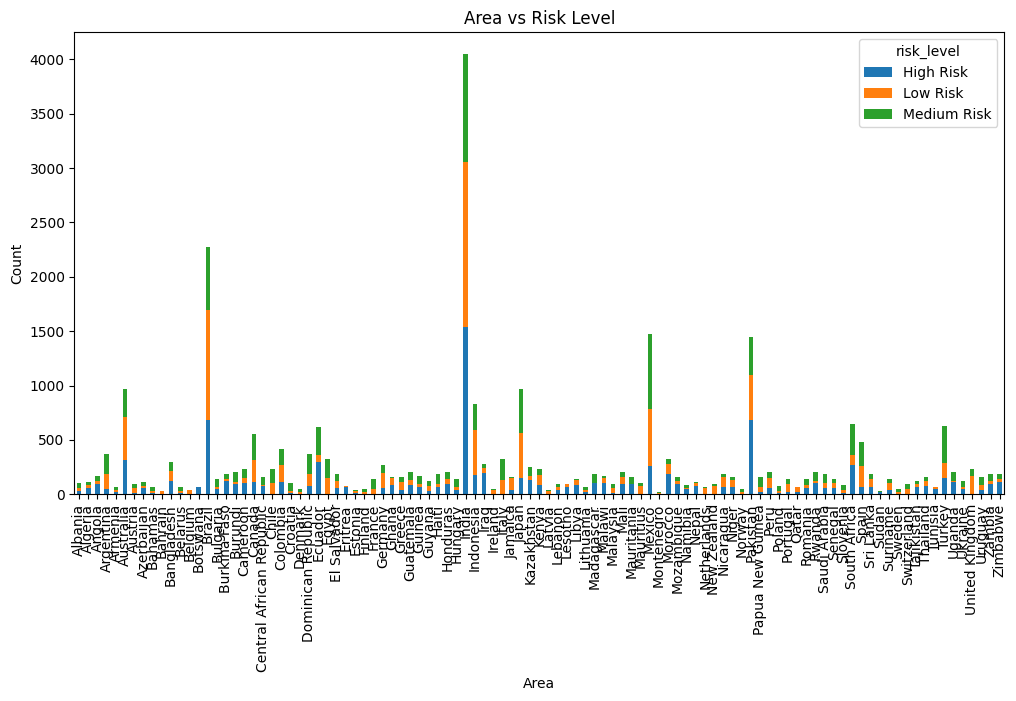

'Countries such as India, Brazil, Mexico, Pakistan, and Australia show high representation across risk categories, with India having the largest dataset presence, indicating broader agricultural diversity.'

In [19]:
#Area V/S Risk 
area_risk = df.groupby(["Area", "risk_level"]).size().unstack()

area_risk.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Area vs Risk Level")
plt.xlabel("Area")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
'''Countries such as India, Brazil, Mexico, Pakistan, and Australia show high representation across risk categories, with India having the largest dataset presence, indicating broader agricultural diversity.'''

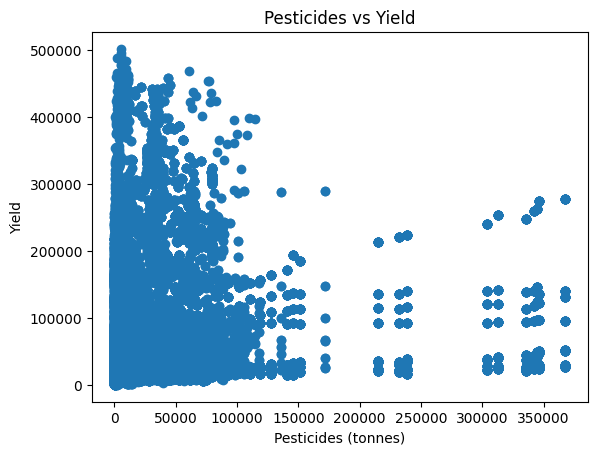

'The relationship between pesticide usage and yield does not show a strong positive correlation. In some cases, higher yields are observed even with lower pesticide usage, suggesting that other environmental factors may play a more significant role'

In [20]:
plt.scatter(df["pesticides_tonnes"], df["hg/ha_yield"])

plt.title("Pesticides vs Yield")
plt.xlabel("Pesticides (tonnes)")
plt.ylabel("Yield")
plt.show()
'''The relationship between pesticide usage and yield does not show a strong positive correlation. In some cases, higher yields are observed even with lower pesticide usage, suggesting that other environmental factors may play a more significant role'''

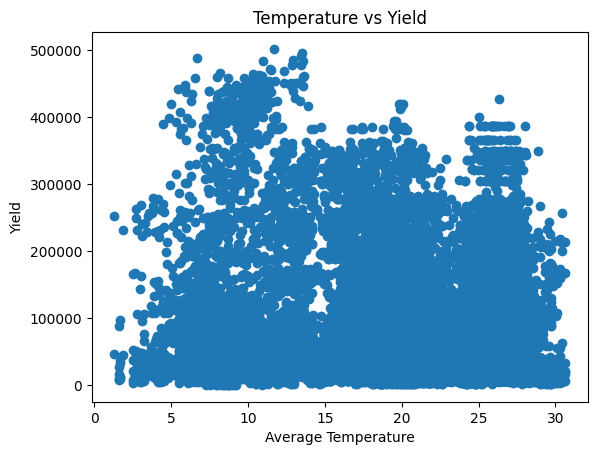

'Yield distribution indicates both high-density regions at moderate to high temperatures and peak yields at relatively lower temperatures, suggesting a non-linear relationship between temperature and crop productivity'

In [21]:
plt.scatter(df["avg_temp"], df["hg/ha_yield"])

plt.title("Temperature vs Yield")
plt.xlabel("Average Temperature")
plt.ylabel("Yield")
plt.show()

'''Yield distribution indicates both high-density regions at moderate to high temperatures and peak yields at relatively lower temperatures, suggesting a non-linear relationship between temperature and crop productivity'''

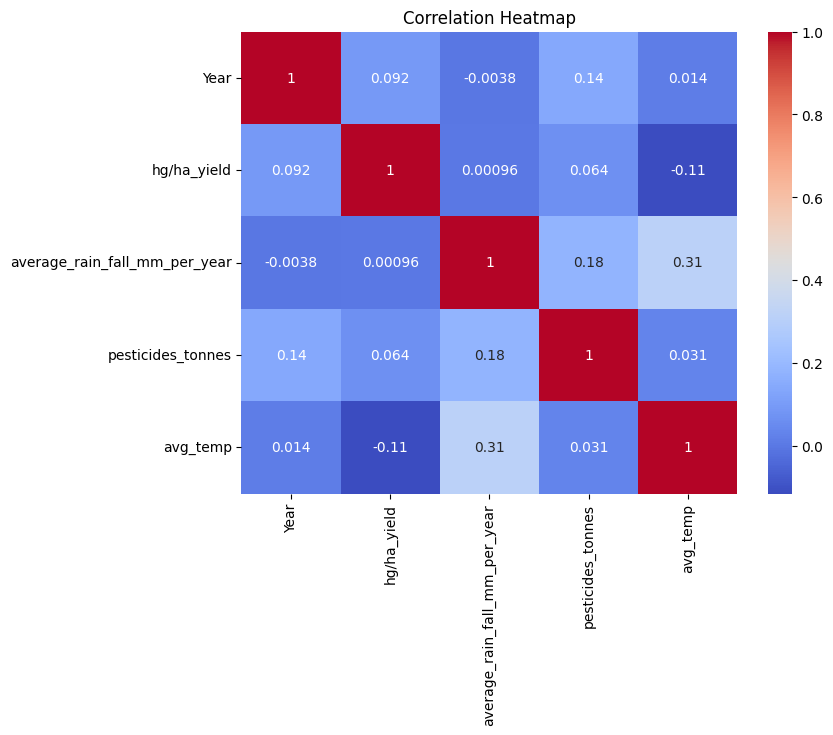

In [22]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()